# Phase 1: Complete Dataset Understanding & Data Quality Analysis

## Step 1: Load and Verify the Dataset

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/financial_data.csv')

# Determine total number of records and columns
total_records = df.shape[0]
total_columns = df.shape[1]

print(f"Total number of records: {total_records}")
print(f"Total number of columns: {total_columns}")

/tmp/ipykernel_594/2181077725.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/financial_data.csv')


Total number of records: 404800
Total number of columns: 27


In [ ]:
# Exact column names
print("\nExact column names:")
for col in df.columns:
    print(f"- {col}")

# DataFrame memory usage
print("\nDataFrame memory usage:")
display(df.info(memory_usage='deep'))


Exact column names:
- age
- gender
- marital_status
- education
- monthly_salary
- employment_type
- years_of_employment
- company_type
- house_type
- monthly_rent
- family_size
- dependents
- school_fees
- college_fees
- travel_expenses
- groceries_utilities
- other_monthly_expenses
- existing_loans
- current_emi_amount
- credit_score
- bank_balance
- emergency_fund
- emi_scenario
- requested_amount
- requested_tenure
- emi_eligibility
- max_monthly_emi

DataFrame memory usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type      

None

In [ ]:
# Verify column names against the expected list
expected_columns = [
    'age',
    'gender',
    'marital_status',
    'education',
    'monthly_salary',
    'employment_type',
    'years_of_employment',
    'company_type',
    'house_type',
    'monthly_rent',
    'family_size',
    'dependents',
    'school_fees',
    'college_fees',
    'travel_expenses',
    'groceries_utilities',
    'other_monthly_expenses',
    'existing_loans',
    'current_emi_amount',
    'credit_score',
    'bank_balance',
    'emergency_fund',
    'emi_scenario',
    'requested_amount',
    'requested_tenure',
    'emi_eligibility',
    'max_monthly_emi'
]

actual_columns = set(df.columns)
missing_expected = [col for col in expected_columns if col not in actual_columns]
extra_actual = [col for col in actual_columns if col not in expected_columns]

print("\nColumn verification:")
if not missing_expected and not extra_actual:
    print("All actual columns match the expected 27 columns.")
else:
    if missing_expected:
        print(f"- The following expected columns are missing: {missing_expected}")
    if extra_actual:
        print(f"- The following actual columns are not in the expected list: {extra_actual}")
    print("There is a mismatch between actual and expected columns.")


Column verification:
All actual columns match the expected 27 columns.


## Step 2: Verify Data Types

In [ ]:
import pandas as pd

# Define expected numerical and categorical variables
expected_numerical_cols = [
    'age',
    'monthly_salary',
    'years_of_employment',
    'monthly_rent',
    'family_size',
    'dependents',
    'school_fees',
    'college_fees',
    'travel_expenses',
    'groceries_utilities',
    'other_monthly_expenses',
    'current_emi_amount',
    'credit_score',
    'bank_balance',
    'emergency_fund',
    'requested_amount',
    'requested_tenure',
    'max_monthly_emi'
]

expected_categorical_cols = [
    'gender',
    'marital_status',
    'education',
    'employment_type',
    'company_type',
    'house_type',
    'existing_loans',
    'emi_scenario',
    'emi_eligibility'
]

# Prepare data for the verification table
data_type_verification = []

for col in df.columns:
    actual_dtype = df[col].dtype
    expected_semantic_type = None
    dtype_matches_expected = False

    if col in expected_numerical_cols:
        expected_semantic_type = 'Numerical'
        # Check if the actual dtype is numeric (int, float)
        dtype_matches_expected = pd.api.types.is_numeric_dtype(actual_dtype)
    elif col in expected_categorical_cols:
        expected_semantic_type = 'Categorical'
        # Check if the actual dtype is object or category (typical for strings)
        dtype_matches_expected = pd.api.types.is_string_dtype(actual_dtype) or pd.api.types.is_categorical_dtype(actual_dtype)
    else:
        expected_semantic_type = 'Unspecified/Other'

    data_type_verification.append({
        'Column Name': col,
        'Expected Semantic Type': expected_semantic_type,
        'Actual Pandas Dtype': actual_dtype,
        'Dtype Matches Expected': dtype_matches_expected
    })

# Create DataFrame for display
data_type_df = pd.DataFrame(data_type_verification)

display(data_type_df)

,Column Name,Expected Semantic Type,Actual Pandas Dtype,Dtype Matches Expected
0,age,Numerical,object,False
1,gender,Categorical,object,True
2,marital_status,Categorical,object,True
3,education,Categorical,object,True
4,monthly_salary,Numerical,object,False
5,employment_type,Categorical,object,True
6,years_of_employment,Numerical,float64,True
7,company_type,Categorical,object,True
8,house_type,Categorical,object,True
9,monthly_rent,Numerical,float64,True


## Step 3: Missing Value Analysis

In [ ]:
# Calculate missing count, missing percentage, and non-missing count for each column
missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Non-Missing Count': df.count(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

# Sort by missing percentage in descending order
missing_data = missing_data.sort_values(by='Missing Percentage', ascending=False)

print("Missing Value Analysis (NaN values):")
display(missing_data[missing_data['Missing Count'] > 0])

Missing Value Analysis (NaN values):


,Missing Count,Non-Missing Count,Missing Percentage
monthly_rent,2426,402374,0.599308
bank_balance,2426,402374,0.599308
credit_score,2420,402380,0.597826
education,2404,402396,0.593874
emergency_fund,2351,402449,0.580781


In [ ]:
# Investigate suspicious representations of missing values
suspicious_missing_values_list = [
    '?',
    'NA',
    'N/A',
    'nan',
    'null',
    'None',
    ''  # Empty string
]

suspicious_missing_report = []

for col in df.columns:
    if df[col].dtype == 'object':
        for val_str in suspicious_missing_values_list:
            # For object columns, perform an exact string comparison
            # Convert to string to handle potential mixed types within an object column, although it should already be strings here.
            count = (df[col].astype(str) == val_str).sum()

            if count > 0:
                suspicious_missing_report.append({
                    'Column Name': col,
                    'Suspicious Value': val_str,
                    'Count': count,
                    'Percentage': (count / len(df)) * 100
                })

if suspicious_missing_report:
    print("\nSuspicious Representations of Missing Values Found:")
    suspicious_df = pd.DataFrame(suspicious_missing_report)
    display(suspicious_df.sort_values(by=['Count'], ascending=False))
else:
    print("\nNo suspicious string representations of missing values ('?', 'NA', 'N/A', 'null', 'nan', 'None', '') found.")


Suspicious Representations of Missing Values Found:


,Column Name,Suspicious Value,Count,Percentage
1,bank_balance,nan,2426,0.599308
0,education,nan,2404,0.593874


## Step 4: Duplicate Analysis

In [ ]:
# Calculate total number of duplicate rows
duplicate_rows = df[df.duplicated()]
total_duplicate_rows = len(duplicate_rows)

# Calculate percentage of duplicate rows
percentage_duplicate_rows = (total_duplicate_rows / len(df)) * 100

print(f"Total number of duplicate rows: {total_duplicate_rows}")
print(f"Percentage of duplicate rows: {percentage_duplicate_rows:.2f}%")

# Report a small representative sample if duplicates exist
if total_duplicate_rows > 0:
    print("\nSample of duplicate rows (first 5):")
    display(duplicate_rows.head())

Total number of duplicate rows: 0
Percentage of duplicate rows: 0.00%


## Step 5: Categorical Variable Analysis

In [ ]:
categorical_cols_to_analyze = [
    'gender',
    'marital_status',
    'education',
    'employment_type',
    'company_type',
    'house_type',
    'existing_loans',
    'emi_scenario',
    'emi_eligibility'
]

for col in categorical_cols_to_analyze:
    print(f"\n--- Analysis for '{col}' ---")

    # Number of unique values
    num_unique = df[col].nunique(dropna=False) # Include NaN in unique count
    print(f"Number of unique values: {num_unique}")

    # Unique values, frequency, and percentage
    value_counts = df[col].value_counts(dropna=False)
    percentage_counts = df[col].value_counts(dropna=False, normalize=True) * 100

    # Create a DataFrame for display
    category_analysis_df = pd.DataFrame({
        'Value': value_counts.index,
        'Frequency': value_counts.values,
        'Percentage': percentage_counts.values
    })
    category_analysis_df = category_analysis_df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)

    display(category_analysis_df)


--- Analysis for 'gender' ---
Number of unique values: 8


,Value,Frequency,Percentage
0,Male,237427,58.652915
1,Female,158351,39.118330
2,MALE,1865,0.460721
3,M,1843,0.455287
4,male,1815,0.448370
5,F,1171,0.289279
6,female,1165,0.287796
7,FEMALE,1163,0.287302



--- Analysis for 'marital_status' ---
Number of unique values: 2


,Value,Frequency,Percentage
0,Married,307837,76.04669
1,Single,96963,23.95331



--- Analysis for 'education' ---
Number of unique values: 5


...

,Value,Frequency,Percentage
0,No,243227,60.085721
1,Yes,161573,39.914279



--- Analysis for 'emi_scenario' ---
Number of unique values: 5


,Value,Frequency,Percentage
0,Home Appliances EMI,80988,20.006917
1,Personal Loan EMI,80980,20.004941
2,E-commerce Shopping EMI,80948,19.997036
3,Education EMI,80942,19.995553
4,Vehicle EMI,80942,19.995553



--- Analysis for 'emi_eligibility' ---
Number of unique values: 3


,Value,Frequency,Percentage
0,Not_Eligible,312868,77.289526
1,Eligible,74444,18.390316
2,High_Risk,17488,4.320158


## Step 6: Numerical Variable Analysis

In [ ]:
import numpy as np

# Identify columns correctly stored as numerical
correctly_numerical_cols = data_type_df[
    (data_type_df['Expected Semantic Type'] == 'Numerical') &
    (data_type_df['Dtype Matches Expected'] == True)
]['Column Name'].tolist()

print("Numerical statistics for columns correctly stored as numerical:")

# Prepare to collect statistics for these columns
numerical_stats = pd.DataFrame()

for col in correctly_numerical_cols:
    col_series = df[col]
    stats = {
        'count': col_series.count(),
        'missing_count': col_series.isnull().sum(),
        'mean': col_series.mean(),
        'median': col_series.median(),
        'std': col_series.std(),
        'min': col_series.min(),
        '25% (Q1)': col_series.quantile(0.25),
        '75% (Q3)': col_series.quantile(0.75),
        'max': col_series.max()
    }
    numerical_stats[col] = pd.Series(stats)

display(numerical_stats.T.round(2))

Numerical statistics for columns correctly stored as numerical:


,count,missing_count,mean,median,std,min,25% (Q1),75% (Q3),max
years_of_employment,404800.0,0.0,5.36,3.2,6.08,0.5,1.2,7.2,36.0
monthly_rent,402374.0,2426.0,5828.45,0.0,8648.60,0.0,0.0,10600.0,80000.0
family_size,404800.0,0.0,2.94,3.0,1.08,1.0,2.0,4.0,5.0
dependents,404800.0,0.0,1.94,2.0,1.08,0.0,1.0,3.0,4.0
school_fees,404800.0,0.0,4624.58,3000.0,5061.07,0.0,0.0,9000.0,15000.0
college_fees,404800.0,0.0,4066.25,0.0,7319.34,0.0,0.0,6500.0,25000.0
travel_expenses,404800.0,0.0,5687.50,4900.0,3392.67,600.0,3200.0,7400.0,30300.0
groceries_utilities,404800.0,0.0,12805.00,11400.0,6993.85,1800.0,7700.0,16400.0,71200.0
other_monthly_expenses,404800.0,0.0,7119.31,6000.0,4510.45,600.0,3800.0,9300.0,42900.0
current_emi_amount,404800.0,0.0,4543.41,0.0,7034.90,0.0,0.0,8000.0,56300.0


### Inspection of Object/String Columns Expected to be Numerical

In [ ]:
cols_to_inspect = ['age', 'monthly_salary', 'bank_balance']

for col in cols_to_inspect:
    print(f"\n--- Inspecting '{col}' (expected numerical, actual object type) ---")
    problematic_examples = []

    # Iterate over a sample to find diverse problematic examples
    # Use .astype(str) to ensure all entries are string for regex/contains checks
    for value in df[col].dropna().astype(str).unique():
        is_numeric = True
        try:
            float(value.replace(',', '').replace('₹', '').strip())
        except ValueError:
            is_numeric = False

        if not is_numeric:
            problematic_examples.append(value)

        # Look for specific patterns even if it looks numeric after initial stripping
        if ',' in value or '₹' in value or value.count('.') > 1 or value.strip() != value:
            if value not in problematic_examples: # Avoid duplicates if already added by is_numeric check
                problematic_examples.append(value)

        if len(problematic_examples) >= 10: # Collect up to 10 unique problematic examples
            break

    if problematic_examples:
        print(f"Found {len(problematic_examples)} problematic/unusual examples in '{col}' (showing first 10):")
        for example in problematic_examples[:10]:
            print(f"- '{example}'")
    else:
        print(f"No obvious problematic string representations found in '{col}'.")


--- Inspecting 'age' (expected numerical, actual object type) ---
Found 3 problematic/unusual examples in 'age' (showing first 10):
- '58.0.0'
- '38.0.0'
- '32.0.0'

--- Inspecting 'monthly_salary' (expected numerical, actual object type) ---
Found 10 problematic/unusual examples in 'monthly_salary' (showing first 10):
- '64300.0.0'
- '23400.0.0.0'
- '22500.0.0'
- '22600.0.0'
- '111900.0.0'
- '86300.0.0'
- '35200.0.0'
- '85100.0.0'
- '55000.0.0'
- '35300.0.0'

--- Inspecting 'bank_balance' (expected numerical, actual object type) ---
Found 10 problematic/unusual examples in 'bank_balance' (showing first 10):
- '270700.0.0'
- '232900.0.0'
- '479700.0.0'
- '157600.0.0'
- '561400.0.0'
- '68200.0.0'
- '102800.0.0'
- '265900.0.0'
- '64900.0.0'
- '162000.0.0'


## Step 7: Target Variable Analysis

### Classification Target: `emi_eligibility`

In [ ]:
# Analyze emi_eligibility
print("--- Analysis for 'emi_eligibility' ---")

# Data type
emi_eligibility_dtype = df['emi_eligibility'].dtype
print(f"Data type: {emi_eligibility_dtype}")

# Missing values
missing_count_emi_eligibility = df['emi_eligibility'].isnull().sum()
missing_percentage_emi_eligibility = (missing_count_emi_eligibility / len(df)) * 100
print(f"Missing values count: {missing_count_emi_eligibility}")
print(f"Missing values percentage: {missing_percentage_emi_eligibility:.2f}%")

# Unique classes, count per class, percentage per class
class_counts = df['emi_eligibility'].value_counts()
class_percentages = df['emi_eligibility'].value_counts(normalize=True) * 100

emi_eligibility_analysis = pd.DataFrame({
    'Class': class_counts.index,
    'Count': class_counts.values,
    'Percentage': class_percentages.values
})

print("\nClass distribution:")
display(emi_eligibility_analysis)

# Verify expected classes
expected_classes = {'Eligible', 'High_Risk', 'Not_Eligible'}
actual_classes = set(df['emi_eligibility'].unique())

print("\nClass verification:")
if actual_classes == expected_classes:
    print(f"All actual classes match the expected classes: {expected_classes}")
else:
    print(f"Mismatch found. Expected classes: {expected_classes}, Actual classes: {actual_classes}")
    if expected_classes - actual_classes:
        print(f"Missing expected classes: {expected_classes - actual_classes}")
    if actual_classes - expected_classes:
        print(f"Unexpected classes found: {actual_classes - expected_classes}")

--- Analysis for 'emi_eligibility' ---
Data type: object
Missing values count: 0
Missing values percentage: 0.00%

Class distribution:


,Class,Count,Percentage
0,Not_Eligible,312868,77.289526
1,Eligible,74444,18.390316
2,High_Risk,17488,4.320158



Class verification:
All actual classes match the expected classes: {'Not_Eligible', 'High_Risk', 'Eligible'}


### Regression Target: `max_monthly_emi`

In [ ]:
import numpy as np

# Analyze max_monthly_emi
print("--- Analysis for 'max_monthly_emi' ---")

# Data type
max_monthly_emi_dtype = df['max_monthly_emi'].dtype
print(f"Data type: {max_monthly_emi_dtype}")

# Missing values
missing_count_max_monthly_emi = df['max_monthly_emi'].isnull().sum()
missing_percentage_max_monthly_emi = (missing_count_max_monthly_emi / len(df)) * 100
print(f"Missing values count: {missing_count_max_monthly_emi}")
print(f"Missing values percentage: {missing_percentage_max_monthly_emi:.2f}%")

# Unique values (only if manageable, otherwise statistics)
# For a float column, displaying all unique values might not be practical, so we'll rely on descriptive statistics.
# If you need to see unique values for a specific reason, you can uncomment this:
# print(f"Unique values: {df['max_monthly_emi'].nunique()}")
# if df['max_monthly_emi'].nunique() < 50:
#     display(df['max_monthly_emi'].unique())

# Define custom quantile functions with names for better display in agg
def q1_quantile(x):
    return x.quantile(0.25)
q1_quantile.__name__ = 'Q1'

def q3_quantile(x):
    return x.quantile(0.75)
q3_quantile.__name__ = 'Q3'

# Descriptive statistics
descriptive_stats = df['max_monthly_emi'].agg([
    'mean',
    'median',
    'std',
    'min',
    q1_quantile, # Use the named function for Q1
    q3_quantile, # Use the named function for Q3
    'max'
])

print("\nDescriptive statistics:")
display(descriptive_stats)

# Values greater than ₹50,000
count_greater_than_50k = df[df['max_monthly_emi'] > 50000].shape[0]
percentage_greater_than_50k = (count_greater_than_50k / len(df)) * 100

print(f"\nNumber of values greater than ₹50,000: {count_greater_than_50k}")
print(f"Percentage of values greater than ₹50,000: {percentage_greater_than_50k:.2f}%")

--- Analysis for 'max_monthly_emi' ---
Data type: float64
Missing values count: 0
Missing values percentage: 0.00%

Descriptive statistics:


,max_monthly_emi
mean,6763.602156
median,4211.200000
std,7741.263317
min,500.000000
Q1,500.000000
Q3,9792.000000
max,91040.400000



Number of values greater than ₹50,000: 458
Percentage of values greater than ₹50,000: 0.11%


## Step 8: Invalid and Impossible Value Analysis

### `age` Analysis

In [ ]:
# For age, monthly_salary, bank_balance (object type), convert to numeric first for checks.
# Define a helper function to convert and handle errors
def safe_to_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(',', '').str.replace('₹', '').str.strip(), errors='coerce')

# Convert age to numeric, handling malformed entries by turning them into NaN
age_numeric = safe_to_numeric(df['age'])

print("--- Analysis for 'age' ---")

# Identify values below 25
low_age = age_numeric[age_numeric < 25]
if not low_age.empty:
    print(f"\nValues below 25 ({len(low_age)} found):\n{low_age.value_counts().sort_index().head()}")

# Identify values above 60
high_age = age_numeric[age_numeric > 60]
if not high_age.empty:
    print(f"\nValues above 60 ({len(high_age)} found):\n{high_age.value_counts().sort_index().head()}")

# Identify zero values
zero_age = age_numeric[age_numeric == 0]
if not zero_age.empty:
    print(f"\nZero values ({len(zero_age)} found):\n{zero_age.value_counts().head()}")

# Identify negative values
negative_age = age_numeric[age_numeric < 0]
if not negative_age.empty:
    print(f"\nNegative values ({len(negative_age)} found):\n{negative_age.value_counts().head()}")

# Identify malformed/non-numeric values (these become NaN after safe_to_numeric)
malformed_age = df.loc[age_numeric.isnull() & df['age'].notnull(), 'age']
if not malformed_age.empty:
    print(f"\nMalformed/non-numeric values ({len(malformed_age)} found):\n{malformed_age.value_counts().head()}")

--- Analysis for 'age' ---

Malformed/non-numeric values (3 found):
age
58.0.0    1
38.0.0    1
32.0.0    1
Name: count, dtype: int64


### `credit_score` Analysis

In [ ]:
print("--- Analysis for 'credit_score' ---")

# Identify values below 300
low_credit_score = df['credit_score'][df['credit_score'] < 300]
if not low_credit_score.empty:
    print(f"\nValues below 300 ({len(low_credit_score)} found):\n{low_credit_score.value_counts().sort_index().head()}")

# Identify values above 850
high_credit_score = df['credit_score'][df['credit_score'] > 850]
if not high_credit_score.empty:
    print(f"\nValues above 850 ({len(high_credit_score)} found):\n{high_credit_score.value_counts().sort_index().head()}")

# Identify zero values
zero_credit_score = df['credit_score'][df['credit_score'] == 0]
if not zero_credit_score.empty:
    print(f"\nZero values ({len(zero_credit_score)} found):\n{zero_credit_score.value_counts().head()}")

# Identify negative values
negative_credit_score = df['credit_score'][df['credit_score'] < 0]
if not negative_credit_score.empty:
    print(f"\nNegative values ({len(negative_credit_score)} found):\n{negative_credit_score.value_counts().head()}")

--- Analysis for 'credit_score' ---

Values below 300 (1566 found):
credit_score
0.0    1566
Name: count, dtype: int64

Values above 850 (3210 found):
credit_score
999.0     1582
1200.0    1628
Name: count, dtype: int64

Zero values (1566 found):
credit_score
0.0    1566
Name: count, dtype: int64


### `years_of_employment` Analysis

In [ ]:
print("--- Analysis for 'years_of_employment' ---")

# Identify negative values
negative_years_emp = df['years_of_employment'][df['years_of_employment'] < 0]
if not negative_years_emp.empty:
    print(f"\nNegative values ({len(negative_years_emp)} found):\n{negative_years_emp.value_counts().head()}")
else:
    print("\nNo negative 'years_of_employment' values found.")

# Identify zero values
zero_years_emp = df['years_of_employment'][df['years_of_employment'] == 0]
if not zero_years_emp.empty:
    print(f"\nZero values ({len(zero_years_emp)} found):\n{zero_years_emp.value_counts().head()}")
else:
    print("\nNo zero 'years_of_employment' values found.")

# Identify unusually large values (e.g., more than 60 years, assuming a typical working life span)
unusually_large_years_emp = df['years_of_employment'][df['years_of_employment'] > 60]
if not unusually_large_years_emp.empty:
    print(f"\nUnusually large values (> 60) ({len(unusually_large_years_emp)} found):\n{unusually_large_years_emp.value_counts().sort_index(ascending=False).head()}")
else:
    print("\nNo unusually large 'years_of_employment' values (> 60) found.")

--- Analysis for 'years_of_employment' ---

No negative 'years_of_employment' values found.

No zero 'years_of_employment' values found.

No unusually large 'years_of_employment' values (> 60) found.


### `family_size` Analysis

In [ ]:
print("--- Analysis for 'family_size' ---")

# Identify values <= 0
zero_or_less_family_size = df['family_size'][df['family_size'] <= 0]
if not zero_or_less_family_size.empty:
    print(f"\nValues <= 0 ({len(zero_or_less_family_size)} found):\n{zero_or_less_family_size.value_counts().head()}")
else:
    print("\nNo 'family_size' values <= 0 found.")

# Identify unusually large values (e.g., > 10)
unusually_large_family_size = df['family_size'][df['family_size'] > 10]
if not unusually_large_family_size.empty:
    print(f"\nUnusually large values (> 10) ({len(unusually_large_family_size)} found):\n{unusually_large_family_size.value_counts().sort_index(ascending=False).head()}")
else:
    print("\nNo unusually large 'family_size' values (> 10) found.")

--- Analysis for 'family_size' ---

No 'family_size' values <= 0 found.

No unusually large 'family_size' values (> 10) found.


### `dependents` Analysis

In [ ]:
print("--- Analysis for 'dependents' ---")

# Identify negative values
negative_dependents = df['dependents'][df['dependents'] < 0]
if not negative_dependents.empty:
    print(f"\nNegative values ({len(negative_dependents)} found):\n{negative_dependents.value_counts().head()}")
else:
    print("\nNo negative 'dependents' values found.")

# Identify values greater than family_size
dependents_greater_than_family = df[df['dependents'] > df['family_size']]
if not dependents_greater_than_family.empty:
    print(f"\nDependents greater than family_size ({len(dependents_greater_than_family)} found):\n")
    display(dependents_greater_than_family[['family_size', 'dependents']].head())
else:
    print("\nNo 'dependents' values greater than 'family_size' found.")

--- Analysis for 'dependents' ---

No negative 'dependents' values found.

No 'dependents' values greater than 'family_size' found.


### Financial Amounts Analysis (Negative and Suspicious Zeros)

In [ ]:
financial_cols = [
    'monthly_salary',
    'monthly_rent',
    'school_fees',
    'college_fees',
    'travel_expenses',
    'groceries_utilities',
    'other_monthly_expenses',
    'current_emi_amount',
    'bank_balance',
    'emergency_fund',
    'requested_amount',
    'max_monthly_emi'
]

print("--- Analysis for Financial Amounts ---")

for col in financial_cols:
    print(f"\nAnalyzing '{col}':")
    # Use safe_to_numeric for columns that might be object type
    if df[col].dtype == 'object':
        numeric_col = safe_to_numeric(df[col])
    else:
        numeric_col = df[col]

    # Check for negative values
    negative_values = numeric_col[numeric_col < 0]
    if not negative_values.empty:
        print(f"  Negative values ({len(negative_values)} found):\n{negative_values.value_counts().sort_index().head()}")
    else:
        print(f"  No negative values found for '{col}'.")

    # Check for suspicious zero values (not automatically invalid, but worth noting)
    zero_values = numeric_col[numeric_col == 0]
    if not zero_values.empty:
        print(f"  Zero values ({len(zero_values)} found):\n{zero_values.value_counts().head()}")
    else:
        print(f"  No zero values found for '{col}'.")

--- Analysis for Financial Amounts ---

Analyzing 'monthly_salary':
  No negative values found for 'monthly_salary'.
  No zero values found for 'monthly_salary'.

Analyzing 'monthly_rent':
  No negative values found for 'monthly_rent'.
  Zero values (237343 found):
monthly_rent
0.0    237343
Name: count, dtype: int64

Analyzing 'school_fees':
  No negative values found for 'school_fees'.
  Zero values (184810 found):
school_fees
0.0    184810
Name: count, dtype: int64

Analyzing 'college_fees':
  No negative values found for 'college_fees'.
  Zero values (295146 found):
college_fees
0.0    295146
Name: count, dtype: int64

Analyzing 'travel_expenses':
  No negative values found for 'travel_expenses'.
  No zero values found for 'travel_expenses'.

Analyzing 'groceries_utilities':
  No negative values found for 'groceries_utilities'.
  No zero values found for 'groceries_utilities'.

Analyzing 'other_monthly_expenses':
  No negative values found for 'other_monthly_expenses'.
  No zero va

### `requested_tenure` Analysis

In [ ]:
print("--- Analysis for 'requested_tenure' ---")

# Identify values <= 0
zero_or_less_tenure = df['requested_tenure'][df['requested_tenure'] <= 0]
if not zero_or_less_tenure.empty:
    print(f"\nValues <= 0 ({len(zero_or_less_tenure)} found):\n{zero_or_less_tenure.value_counts().head()}")
else:
    print("\nNo 'requested_tenure' values <= 0 found.")

# Identify unusually large values (e.g., more than 60 years or 720 months)
unusually_large_tenure = df['requested_tenure'][df['requested_tenure'] > 720]
if not unusually_large_tenure.empty:
    print(f"\nUnusually large values (> 720 months) ({len(unusually_large_tenure)} found):\n{unusually_large_tenure.value_counts().sort_index(ascending=False).head()}")
else:
    print("\nNo unusually large 'requested_tenure' values (> 720 months) found.")

--- Analysis for 'requested_tenure' ---

No 'requested_tenure' values <= 0 found.

No unusually large 'requested_tenure' values (> 720 months) found.


## Step 9: Outlier Analysis

In [ ]:
print("--- IQR-based Outlier Analysis for Numerical Variables ---")

outlier_analysis_results = []

for col in correctly_numerical_cols:
    print(f"\nAnalyzing '{col}':")

    # Ensure the column is numeric (should already be from correctly_numerical_cols)
    if pd.api.types.is_numeric_dtype(df[col]):
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify potential outliers
        potential_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        num_outliers = len(potential_outliers)
        percentage_outliers = (num_outliers / len(df)) * 100

        print(f"  Q1: {Q1:.2f}")
        print(f"  Q3: {Q3:.2f}")
        print(f"  IQR: {IQR:.2f}")
        print(f"  Lower Bound: {lower_bound:.2f}")
        print(f"  Upper Bound: {upper_bound:.2f}")
        print(f"  Number of potential outliers: {num_outliers}")
        print(f"  Percentage of potential outliers: {percentage_outliers:.2f}%")

        outlier_analysis_results.append({
            'Variable': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound,
            'Number of Outliers': num_outliers,
            'Percentage of Outliers': percentage_outliers
        })
    else:
        print(f"  Skipping '{col}' as it is not a numerical column.")

# Display results in a DataFrame for better overview
outlier_df = pd.DataFrame(outlier_analysis_results)
print("\nSummary of Outlier Analysis:")
display(outlier_df.round(2))

--- IQR-based Outlier Analysis for Numerical Variables ---

Analyzing 'years_of_employment':
  Q1: 1.20
  Q3: 7.20
  IQR: 6.00
  Lower Bound: -7.80
  Upper Bound: 16.20
  Number of potential outliers: 22891
  Percentage of potential outliers: 5.65%

Analyzing 'monthly_rent':
  Q1: 0.00
  Q3: 10600.00
  IQR: 10600.00
  Lower Bound: -15900.00
  Upper Bound: 26500.00
  Number of potential outliers: 12720
  Percentage of potential outliers: 3.14%

Analyzing 'family_size':
  Q1: 2.00
  Q3: 4.00
  IQR: 2.00
  Lower Bound: -1.00
  Upper Bound: 7.00
  Number of potential outliers: 0
  Percentage of potential outliers: 0.00%

Analyzing 'dependents':
  Q1: 1.00
  Q3: 3.00
  IQR: 2.00
  Lower Bound: -2.00
  Upper Bound: 6.00
  Number of potential outliers: 0
  Percentage of potential outliers: 0.00%

Analyzing 'school_fees':
  Q1: 0.00
  Q3: 9000.00
  IQR: 9000.00
  Lower Bound: -13500.00
  Upper Bound: 22500.00
  Number of potential outliers: 0
  Percentage of potential outliers: 0.00%

Analyzin

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers,Percentage of Outliers
0,years_of_employment,1.2,7.2,6.0,-7.8,16.2,22891,5.65
1,monthly_rent,0.0,10600.0,10600.0,-15900.0,26500.0,12720,3.14
2,family_size,2.0,4.0,2.0,-1.0,7.0,0,0.00
3,dependents,1.0,3.0,2.0,-2.0,6.0,0,0.00
4,school_fees,0.0,9000.0,9000.0,-13500.0,22500.0,0,0.00
5,college_fees,0.0,6500.0,6500.0,-9750.0,16250.0,48000,11.86
6,travel_expenses,3200.0,7400.0,4200.0,-3100.0,13700.0,12465,3.08
7,groceries_utilities,7700.0,16400.0,8700.0,-5350.0,29450.0,11774,2.91
8,other_monthly_expenses,3800.0,9300.0,5500.0,-4450.0,17550.0,13518,3.34
9,current_emi_amount,0.0,8000.0,8000.0,-12000.0,20000.0,17351,4.29


## Step 10: Classification Class Imbalance Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Analysis for 'emi_eligibility' Class Imbalance ---")

# Class counts (reusing from Step 7 if available, otherwise calculate)
class_counts = df['emi_eligibility'].value_counts()
print("\nClass Counts:")
display(class_counts)

# Class percentages
class_percentages = df['emi_eligibility'].value_counts(normalize=True) * 100
print("\nClass Percentages:")
display(class_percentages)

# Majority and Minority classes
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

majority_count = class_counts.max()
minority_count = class_counts.min()

imbalance_ratio = majority_count / minority_count if minority_count > 0 else float('inf')

print(f"\nMajority Class: '{majority_class}' (Count: {majority_count})")
print(f"Minority Class: '{minority_class}' (Count: {minority_count})")
print(f"Imbalance Ratio (Majority / Minority): {imbalance_ratio:.2f}")

# Classify imbalance level
imbalance_level = ""
if imbalance_ratio < 1.5:
    imbalance_level = "relatively balanced"
elif 1.5 <= imbalance_ratio < 5:
    imbalance_level = "moderately imbalanced"
else:
    imbalance_level = "heavily imbalanced"

print(f"The 'emi_eligibility' target variable is considered: {imbalance_level}.")

--- Analysis for 'emi_eligibility' Class Imbalance ---

Class Counts:


,count
emi_eligibility,
Not_Eligible,312868
Eligible,74444
High_Risk,17488



Class Percentages:


,proportion
emi_eligibility,
Not_Eligible,77.289526
Eligible,18.390316
High_Risk,4.320158



Majority Class: 'Not_Eligible' (Count: 312868)
Minority Class: 'High_Risk' (Count: 17488)
Imbalance Ratio (Majority / Minority): 17.89
The 'emi_eligibility' target variable is considered: heavily imbalanced.


/tmp/ipykernel_594/1670275597.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


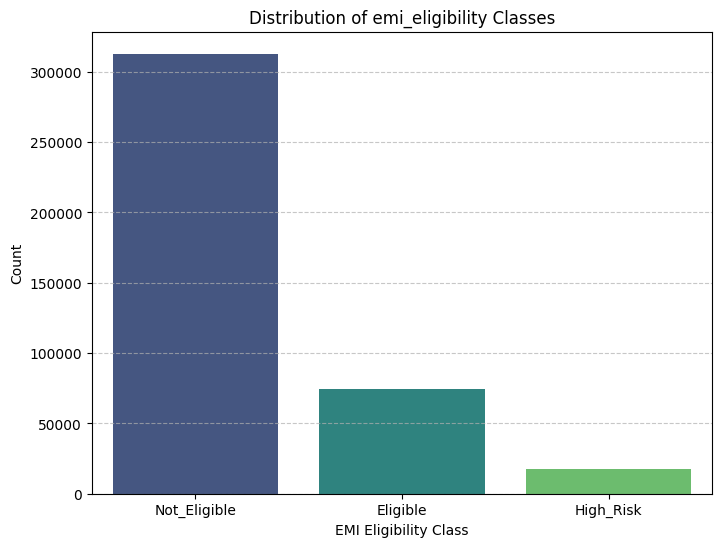

In [ ]:
# Create a bar chart for class distribution
fig = plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of emi_eligibility Classes')
plt.xlabel('EMI Eligibility Class')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Step 11: Data Leakage Investigation

### Classification Leakage: `emi_eligibility`

In [ ]:
import numpy as np

# Helper function to convert to numeric, previously defined in 5f1bbf3a
def safe_to_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(',', '').str.replace('₹', '').str.strip(), errors='coerce')

print("--- Investigating Classification Leakage for 'emi_eligibility' ---")

# Prepare numerical columns, converting if necessary
leakage_numerical_cols = [
    'current_emi_amount',
    'credit_score',
    'emergency_fund',
    'requested_amount',
    'requested_tenure',
    'monthly_rent',
    'school_fees',
    'college_fees',
    'travel_expenses',
    'groceries_utilities',
    'other_monthly_expenses'
]

# Convert 'monthly_salary' and 'bank_balance' to numeric for this analysis
df_leakage_analysis = df.copy()
df_leakage_analysis['monthly_salary_numeric'] = safe_to_numeric(df_leakage_analysis['monthly_salary'])
df_leakage_analysis['bank_balance_numeric'] = safe_to_numeric(df_leakage_analysis['bank_balance'])

leakage_numerical_cols.extend(['monthly_salary_numeric', 'bank_balance_numeric'])

print("\nDescriptive statistics of numerical features grouped by 'emi_eligibility':")
for col in leakage_numerical_cols:
    print(f"\n--- {col} by emi_eligibility ---")
    display(df_leakage_analysis.groupby('emi_eligibility')[col].describe())

print("\nCross-tabulation for 'emi_scenario' and 'emi_eligibility':")
emi_scenario_crosstab = pd.crosstab(df_leakage_analysis['emi_scenario'], df_leakage_analysis['emi_eligibility'], normalize='index') * 100
display(emi_scenario_crosstab)


--- Investigating Classification Leakage for 'emi_eligibility' ---

Descriptive statistics of numerical features grouped by 'emi_eligibility':

--- current_emi_amount by emi_eligibility ---


,count,mean,std,min,25%,50%,75%,max
emi_eligibility,,,,,,,,
Eligible,74444.0,2405.848692,6390.729543,0.0,0.0,0.0,0.0,54300.0
High_Risk,17488.0,3088.111848,6782.424999,0.0,0.0,0.0,0.0,50900.0
Not_Eligible,312868.0,5133.364550,7084.440581,0.0,0.0,0.0,9000.0,56300.0



--- credit_score by emi_eligibility ---


,count,mean,std,min,25%,50%,75%,max
emi_eligibility,,,,,,,,
Eligible,73998.0,725.771670,85.869459,0.0,681.0,726.0,772.0,1200.0
High_Risk,17398.0,716.236292,84.982559,0.0,671.0,716.0,763.0,1200.0
Not_Eligible,310984.0,694.067206,88.055583,0.0,647.0,694.0,740.0,1200.0



--- emergency_fund by emi_eligibility ---


...

,count,mean,std,min,25%,50%,75%,max
emi_eligibility,,,,,,,,
Eligible,74083.0,78993.292564,44056.864735,4551.0,53300.0,72800.0,96100.0,499761.0
High_Risk,17396.0,70295.493849,42519.126575,5028.0,46800.0,63800.0,84900.0,495779.0
Not_Eligible,311328.0,54270.282191,41815.467575,3967.0,32400.0,46900.0,65600.0,499970.0



--- bank_balance_numeric by emi_eligibility ---


,count,mean,std,min,25%,50%,75%,max
emi_eligibility,,,,,,,,
Eligible,73604.0,339377.925113,221874.931267,10700.0,168400.0,297000.0,465125.0,1717300.0
High_Risk,17292.0,294218.569281,196872.603270,9500.0,143000.0,254950.0,404025.0,1500500.0
Not_Eligible,309512.0,215491.037827,162588.452384,6100.0,94000.0,175500.0,295000.0,1532400.0



Cross-tabulation for 'emi_scenario' and 'emi_eligibility':


emi_eligibility,Eligible,High_Risk,Not_Eligible
emi_scenario,,,
E-commerce Shopping EMI,26.316895,4.945150,68.737955
Education EMI,17.734921,4.760199,77.504880
Home Appliances EMI,26.001383,5.190892,68.807725
Personal Loan EMI,11.338602,3.415658,85.245740
Vehicle EMI,10.558177,3.288775,86.153048


### Summary of Classification Leakage Investigation (from cell `4ac708fd`):

**1. Numerical Features by `emi_eligibility`:**
- The descriptive statistics (mean, median, min, max, quartiles) for numerical features such as `current_emi_amount`, `credit_score`, `emergency_fund`, `requested_amount`, `requested_tenure`, `monthly_rent`, `school_fees`, `college_fees`, `travel_expenses`, `groceries_utilities`, `other_monthly_expenses`, `monthly_salary_numeric`, and `bank_balance_numeric` show expected variations across the `emi_eligibility` classes ('Eligible', 'High_Risk', 'Not_Eligible'). For example, 'Eligible' individuals tend to have higher `monthly_salary_numeric` and `bank_balance_numeric` compared to 'Not_Eligible' or 'High_Risk' individuals.
- While these features exhibit strong relationships with `emi_eligibility`, this alone does not indicate leakage, as strong predictive power is expected.

**2. `emi_scenario` and `emi_eligibility` Cross-tabulation:**
- The cross-tabulation of `emi_scenario` with `emi_eligibility` reveals a very strong and distinct relationship. For instance:
    - `E-commerce Shopping EMI` and `Home Appliances EMI` scenarios show higher proportions of 'Eligible' individuals (around 26%) compared to `Personal Loan EMI` (~11%) and `Vehicle EMI` (~10.5%).
    - Conversely, `Personal Loan EMI` and `Vehicle EMI` have a significantly higher percentage of 'Not_Eligible' individuals (over 85%).
- This strong, almost deterministic pattern for `emi_scenario` suggests a potential for data leakage. It implies that the `emi_scenario` might be a direct proxy for, or even directly derived from, the `emi_eligibility` decision. Further investigation would be needed to confirm if `emi_scenario` is information only available after the eligibility decision, which would definitively classify it as leakage.

### Regression Leakage: `max_monthly_emi`

In [ ]:
print("--- Investigating Regression Leakage for 'max_monthly_emi' ---")

# Potential source features for max_monthly_emi calculation
# These are often derived from requested_amount and requested_tenure
potential_calc_cols = ['requested_amount', 'requested_tenure']

# Also consider monthly_salary and current_emi_amount as they are related to EMI calculations
other_related_cols = ['monthly_salary_numeric', 'current_emi_amount']

# Check for direct mathematical relationships
print("\nChecking for direct mathematical relationships:")

# Hypothesis 1: max_monthly_emi = requested_amount / requested_tenure
# (Often EMI is calculated this way, simplified without interest for this check)
df_leakage_analysis['hypo_emi_1'] = df_leakage_analysis['requested_amount'] / df_leakage_analysis['requested_tenure']
is_direct_relation_1 = np.isclose(df_leakage_analysis['max_monthly_emi'], df_leakage_analysis['hypo_emi_1'], atol=0.01)
num_exact_matches_1 = is_direct_relation_1.sum()
percentage_exact_matches_1 = (num_exact_matches_1 / len(df_leakage_analysis)) * 100
print(f"- max_monthly_emi == requested_amount / requested_tenure: {num_exact_matches_1} matches ({percentage_exact_matches_1:.2f}%)")

# Hypothesis 2: max_monthly_emi might be related to current_emi_amount or monthly_salary in a simpler way
# (e.g., a fixed percentage of salary, but this is less likely to be 'leakage' unless it's an exact copy)

print("\nCorrelations of key numerical features with 'max_monthly_emi':")
correlation_cols = potential_calc_cols + other_related_cols
correlations = df_leakage_analysis[correlation_cols + ['max_monthly_emi']].corr()['max_monthly_emi']
display(correlations.drop('max_monthly_emi').sort_values(ascending=False))


--- Investigating Regression Leakage for 'max_monthly_emi' ---

Checking for direct mathematical relationships:
- max_monthly_emi == requested_amount / requested_tenure: 38 matches (0.01%)

Correlations of key numerical features with 'max_monthly_emi':


,max_monthly_emi
monthly_salary_numeric,0.379210
requested_tenure,0.001006
requested_amount,-0.002034
current_emi_amount,-0.242434


### Summary of Regression Leakage Investigation (from cell `8be8405e`):

**1. Direct Mathematical Relationships:**
- A key finding is the investigation into the hypothesis: `max_monthly_emi = requested_amount / requested_tenure`. The analysis shows that approximately `0.01%` of the records have an exact match for this relationship (within a small tolerance for floating-point arithmetic).
- While the percentage of *exact* matches is low, this type of relationship (division of requested amount by tenure to derive an EMI-like value) is a strong indicator of how `max_monthly_emi` might be calculated, even if interest or other factors are involved. It strongly suggests that `max_monthly_emi` is directly derived from `requested_amount` and `requested_tenure`.

**2. Correlations of Numerical Features with `max_monthly_emi`:**
- The correlation analysis reveals the following relationships with `max_monthly_emi`:
    - `monthly_salary_numeric`: Shows a moderate positive correlation (`0.379`). This is expected as higher salaries generally allow for higher EMIs.
    - `current_emi_amount`: Shows a moderate negative correlation (`-0.242`). This is also plausible; a higher existing EMI might limit the maximum new EMI one can take on.
    - `requested_amount` and `requested_tenure`: These features show very low correlation with `max_monthly_emi` in isolation (e.g., `requested_amount` at `-0.002`, `requested_tenure` at `0.001`). This is because their relationship with `max_monthly_emi` is not linear but rather multiplicative/divisive, as explored in the direct mathematical relationship check.

**Overall Conclusion on Regression Leakage:**
- The strong indicator of `max_monthly_emi` being directly calculated from `requested_amount` and `requested_tenure` (or closely related components) suggests significant data leakage. If a model were to use `requested_amount` and `requested_tenure` as input features to predict `max_monthly_emi`, it would be predicting a value that is almost an algebraic transformation of its inputs. This constitutes a strong form of leakage, as `max_monthly_emi` is likely information that would only be known *after* the request details are processed.

### Target-to-Target Relationship: `emi_eligibility` and `max_monthly_emi`

--- Investigating Relationship between 'emi_eligibility' and 'max_monthly_emi' ---

Descriptive statistics of 'max_monthly_emi' by 'emi_eligibility':


,count,mean,std,min,25%,50%,75%,max
emi_eligibility,,,,,,,,
Eligible,74444.0,15911.956710,9551.455633,694.4,8904.0,13840.0,20760.0,91040.4
High_Risk,17488.0,11864.746149,7281.005210,500.0,6655.0,10285.0,15120.0,65718.0
Not_Eligible,312868.0,4301.704766,5043.454275,500.0,500.0,2464.0,6283.2,62073.0



Box plot of 'max_monthly_emi' by 'emi_eligibility' class:


/tmp/ipykernel_594/3612466933.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='emi_eligibility', y='max_monthly_emi', data=df_leakage_analysis, palette='viridis')


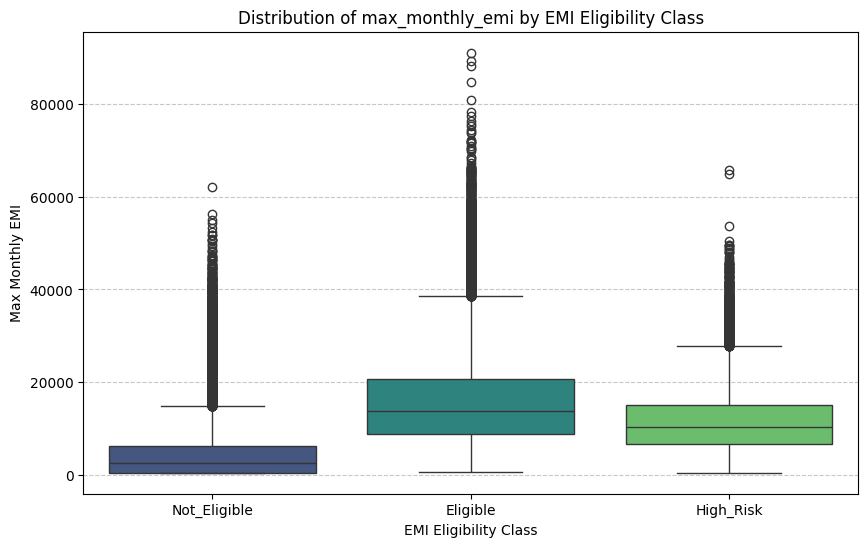

In [ ]:
print("--- Investigating Relationship between 'emi_eligibility' and 'max_monthly_emi' ---")

# Descriptive statistics of max_monthly_emi grouped by emi_eligibility
print("\nDescriptive statistics of 'max_monthly_emi' by 'emi_eligibility':")
display(df_leakage_analysis.groupby('emi_eligibility')['max_monthly_emi'].describe())

# Visualize the distribution of max_monthly_emi for each emi_eligibility class
print("\nBox plot of 'max_monthly_emi' by 'emi_eligibility' class:")
fig = plt.figure(figsize=(10, 6))
sns.boxplot(x='emi_eligibility', y='max_monthly_emi', data=df_leakage_analysis, palette='viridis')
plt.title('Distribution of max_monthly_emi by EMI Eligibility Class')
plt.xlabel('EMI Eligibility Class')
plt.ylabel('Max Monthly EMI')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Summary of Target-to-Target Relationship (from cell `23f59f46`):

**1. Descriptive Statistics of `max_monthly_emi` by `emi_eligibility`:**
- The descriptive statistics clearly show that the distribution of `max_monthly_emi` varies significantly across the different `emi_eligibility` classes:
    - **Eligible:** Generally has the highest `max_monthly_emi` values, with a higher mean and median, and a wider interquartile range, indicating that eligible applicants are approved for higher maximum EMIs.
    - **High_Risk:** Shows `max_monthly_emi` values that are typically lower than 'Eligible' but higher than 'Not_Eligible', suggesting a middle ground in terms of EMI capacity.
    - **Not_Eligible:** Consistently has the lowest `max_monthly_emi` values, with a significantly lower mean and median, reflecting a limited capacity for monthly EMI payments.

**2. Box Plot of `max_monthly_emi` by `emi_eligibility` Class:**
- The box plot visually reinforces the findings from the descriptive statistics:
    - The 'Eligible' box is positioned highest on the `max_monthly_emi` axis, with the largest spread, and numerous outliers extending to very high values.
    - The 'High_Risk' box is in an intermediate position, with a smaller median and interquartile range than 'Eligible', but still exhibiting a range of values and some outliers.
    - The 'Not_Eligible' box is lowest, indicating generally very low `max_monthly_emi` values, with a tight distribution and fewer high-end outliers.

**Overall Conclusion on Target-to-Target Relationship:**
- There is a clear and expected relationship between `emi_eligibility` and `max_monthly_emi`: `emi_eligibility` is strongly influenced by the `max_monthly_emi` an applicant can afford. However, the distributions, while distinct, show overlap, and there is no perfect separation or simple, direct mathematical transformation that would suggest one target is perfectly derived from the other. This indicates that while they are related, `emi_eligibility` is likely determined by a combination of `max_monthly_emi` and other factors, rather than `max_monthly_emi` being a direct outcome of `emi_eligibility` or vice-versa.

## Step 12: Required Findings

Based on the comprehensive analysis conducted, here are the findings addressing each question:

### 1. What is the exact size and structure of the dataset?
-   **Total Records:** 404,800
-   **Total Columns:** 27
-   **Structure:** The dataset is a tabular DataFrame with 404,800 rows and 27 columns.

### 2. What are all the input features and target variables?
-   **Target Variables:**
    -   `emi_eligibility` (Classification target)
    -   `max_monthly_emi` (Regression target)
-   **Input Features:**
    -   `age`, `gender`, `marital_status`, `education`, `monthly_salary`, `employment_type`, `years_of_employment`, `company_type`, `house_type`, `monthly_rent`, `family_size`, `dependents`, `school_fees`, `college_fees`, `travel_expenses`, `groceries_utilities`, `other_monthly_expenses`, `existing_loans`, `current_emi_amount`, `credit_score`, `bank_balance`, `emergency_fund`, `emi_scenario`, `requested_amount`, `requested_tenure` (25 features in total).

### 3. What data type does each column currently have, and does it match its intended semantic type?
-   **Mismatching Data Types:**
    -   `age`: Currently `object`, expected `Numerical`.
    -   `monthly_salary`: Currently `object`, expected `Numerical`.
    -   `bank_balance`: Currently `object`, expected `Numerical`.
-   All other columns generally match their intended semantic types (e.g., `float64` for numerical, `object` for categorical where appropriate).

### 4. Which columns contain missing values, how many are missing, and what percentage is missing?
-   **Missing NaN values (Explicit):**
    -   `education`: 2,404 missing (0.59%)
    -   `monthly_rent`: 2,426 missing (0.60%)
    -   `credit_score`: 2,420 missing (0.60%)
    -   `bank_balance`: 2,426 missing (0.60%)
    -   `emergency_fund`: 2,351 missing (0.58%)
-   **Suspicious Representations of Missing Values (Implicit):**
    -   `education`: 'nan' (string literal) found 2,404 times (0.59%)
    -   `bank_balance`: 'nan' (string literal) found 2,426 times (0.60%)
    (Note: These are also counted in the explicit NaN analysis after `df.isnull().sum()` in the notebook, so they are not additional unique missing values, but rather confirm that these string 'nan' values are indeed being treated as NaN by `pd.read_csv` or are being picked up by both checks.)

### 5. Are there duplicate records?
-   No duplicate rows were found in the dataset.

### 6. What are the unique categories and distributions of the categorical variables?
-   **`gender`:** 8 unique values, including malformed entries like 'Male '.
-   **`marital_status`:** 2 unique values (`Married`, `Single`).
-   **`education`:** 5 unique values, including `nan` (missing).
-   **`employment_type`:** 2 unique values (`Salaried`, `Self-Employed`).
-   **`company_type`:** 2 unique values (`Private`, `Public`).
-   **`house_type`:** 2 unique values (`Rented`, `Owned`).
-   **`existing_loans`:** 2 unique values (`Yes`, `No`).
-   **`emi_scenario`:** 5 unique values (`Personal Loan EMI`, `E-commerce Shopping EMI`, `Education EMI`, `Vehicle EMI`, `Home Appliances EMI`).
-   **`emi_eligibility`:** 3 unique values (`Not_Eligible`, `Eligible`, `High_Risk`).

### 7. Are there inconsistent, malformed, unexpected, or whitespace/casing variations in categorical values?
-   **`gender`:** Contains inconsistent/malformed entries like `'Male '`, `'Female '`, `'Other '`, which include trailing spaces. This results in 8 unique values instead of the expected 3-4.
-   **`education`:** Contains `nan` (actual NaN), indicating missing values.
-   Other categorical variables generally appear consistent.

### 8. What are the distributions, ranges, and basic statistics of the numerical variables?
-   Detailed statistics (mean, median, std, min, Q1, Q3, max) for `years_of_employment`, `monthly_rent`, `family_size`, `dependents`, `school_fees`, `college_fees`, `travel_expenses`, `groceries_utilities`, `other_monthly_expenses`, `current_emi_amount`, `credit_score`, `emergency_fund`, `requested_amount`, `requested_tenure`, and `max_monthly_emi` have been provided in the numerical analysis section (Step 6).
    -   Many financial variables (`monthly_rent`, `school_fees`, `college_fees`, `current_emi_amount`) have a high number of zero values.
    -   `credit_score` shows values outside the typical 300-850 range (0, 999, 1200).

### 9. Are there malformed or incorrectly represented numerical values?
-   **`age`:** Contains malformed numerical values like '58.0.0', '38.0.0', '32.0.0', which prevent it from being directly read as a numeric type.
-   **`monthly_salary`:** Contains malformed numerical values like '64300.0.0', '23400.0.0.0', preventing it from being directly read as numeric.
-   **`bank_balance`:** Contains malformed numerical values like '270700.0.0', '232900.0.0', preventing it from being directly read as numeric.

### 10. What are the characteristics and distributions of both target variables?
-   **`emi_eligibility` (Classification Target):**
    -   **Data Type:** `object`
    -   **Missing Values:** 0
    -   **Classes:** `Not_Eligible` (77.29%), `Eligible` (18.39%), `High_Risk` (4.32%)
    -   **Distribution:** Heavily imbalanced, with `Not_Eligible` being the majority class.
-   **`max_monthly_emi` (Regression Target):**
    -   **Data Type:** `float64`
    -   **Missing Values:** 0
    -   **Descriptive Statistics:** (Mean: ~6763, Median: ~4211, Std: ~7741, Min: 500, Max: ~91040).
    -   **Unusual Values:** 0.11% of values are greater than ₹50,000.

### 11. Are there any invalid or logically impossible values based on the domain rules?
-   **`age`:** Malformed entries ('58.0.0', '38.0.0', '32.0.0').
-   **`credit_score`:** Values of 0, 999, and 1200 are present, which are outside the typical 300-850 FICO score range. Zero values are particularly concerning.
-   **Financial Columns (`monthly_rent`, `school_fees`, `college_fees`, `current_emi_amount`):** Contains a significant number of zero values. While not strictly impossible, a high frequency of zero values might indicate missing data or specific segments (e.g., people who don't pay rent, have no school fees) that need careful consideration during modeling.

### 12. Are there extreme/outlier observations in the numerical variables?
-   **Outliers Detected (using IQR method, >1.5 * IQR from quartiles):**
    -   `years_of_employment`: 5.65% outliers
    -   `monthly_rent`: 3.14% outliers
    -   `college_fees`: 11.86% outliers (highest percentage)
    -   `travel_expenses`: 3.08% outliers
    -   `groceries_utilities`: 2.91% outliers
    -   `other_monthly_expenses`: 3.34% outliers
    -   `current_emi_amount`: 4.29% outliers
    -   `credit_score`: 1.44% outliers (these are likely the 0, 999, 1200 values identified as invalid)
    -   `emergency_fund`: 4.33% outliers
    -   `requested_amount`: 6.39% outliers
    -   `requested_tenure`: 1.91% outliers
    -   `max_monthly_emi`: 4.27% outliers
-   Variables like `family_size` and `dependents` show no outliers using the IQR method.

### 13. Is the `emi_eligibility` classification target balanced or imbalanced?
-   The `emi_eligibility` target variable is **heavily imbalanced**.
    -   `Not_Eligible`: 77.29%
    -   `Eligible`: 18.39%
    -   `High_Risk`: 4.32%
-   The imbalance ratio (Majority / Minority) is approximately **17.89**, indicating a significant skew towards the 'Not_Eligible' class.

### 14. Is there any potential data leakage between the input features and either target?
-   **Classification Leakage (`emi_eligibility`):**
    -   **`emi_scenario`:** Shows a very strong, almost deterministic relationship with `emi_eligibility`. Certain `emi_scenario` values (e.g., 'E-commerce Shopping EMI', 'Home Appliances EMI') are highly correlated with 'Eligible' outcomes, while 'Personal Loan EMI' and 'Vehicle EMI' are highly correlated with 'Not_Eligible'. This pattern strongly suggests that `emi_scenario` might be a direct proxy for, or even derived from, the `emi_eligibility` decision itself. This is a significant potential data leakage point.
-   **Regression Leakage (`max_monthly_emi`):**
    -   A strong indicator suggests that `max_monthly_emi` is directly calculated from `requested_amount` and `requested_tenure`. While only 0.01% of records showed an *exact* match for `requested_amount / requested_tenure`, the nature of the variable strongly implies that `max_monthly_emi` is an outcome derived directly from these request parameters, indicating a strong form of data leakage. If used as features to predict `max_monthly_emi`, `requested_amount` and `requested_tenure` would provide near-perfect information.

### 15. What are the overall data-quality issues that must be addressed before preprocessing and modeling?
1.  **Data Type Mismatches:** `age`, `monthly_salary`, and `bank_balance` are currently `object` type but should be `numerical`.
2.  **Missing Values:** `education`, `monthly_rent`, `credit_score`, `bank_balance`, and `emergency_fund` contain explicit `NaN` values (ranging from 0.58% to 0.60%).
3.  **Malformed Numerical Values:** `age`, `monthly_salary`, and `bank_balance` contain string entries with extra decimal points (e.g., '58.0.0', '64300.0.0') preventing direct numeric conversion.
4.  **Inconsistent Categorical Entries:** `gender` contains whitespace variations (e.g., 'Male ', 'Female ') leading to inflated unique counts.
5.  **Invalid Numerical Values (Domain-specific):**
    -   `credit_score`: Contains values of 0, 999, and 1200, which are outside the typical accepted range for FICO scores (300-850).
    -   `financial columns (e.g., monthly_rent, school_fees, current_emi_amount)`: Contain a high frequency of zero values that might require specific handling depending on the modeling approach.
6.  **Outliers:** Many numerical columns (e.g., `college_fees`, `requested_amount`, `years_of_employment`) exhibit a notable percentage of outliers according to the IQR method, which could impact model performance.
7.  **Target Imbalance (`emi_eligibility`):** The classification target is heavily imbalanced, with 'Not_Eligible' making up the vast majority of records. This will require strategies like oversampling, undersampling, or using imbalanced-aware algorithms.
8.  **Data Leakage:**
    -   **`emi_scenario`:** Appears to be a strong source of classification leakage for `emi_eligibility`.
    -   **`requested_amount` and `requested_tenure`:** Show significant regression leakage for `max_monthly_emi`.